In [1]:
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("chickwts.csv")

In [3]:
df

,Unnamed: 0,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean
...,...,...,...
66,67,359,casein
67,68,216,casein
68,69,222,casein
69,70,283,casein


In [4]:
df.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

In [5]:
sorted_feed = df.groupby("feed")["weight"].mean().sort_values(ascending=True).index
sorted_feed

Index(['horsebean', 'linseed', 'soybean', 'meatmeal', 'casein', 'sunflower'], dtype='str', name='feed')

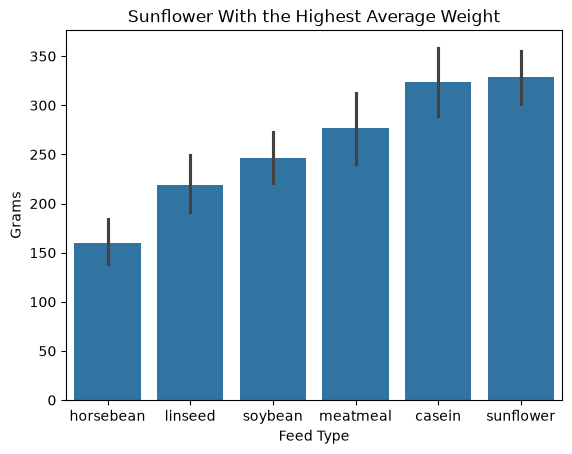

In [6]:
sns.barplot(data=df, x="feed", y="weight", order=sorted_feed)
plt.title("Sunflower With the Highest Average Weight")
plt.xlabel("Feed Type")
plt.ylabel("Grams")
plt.show()

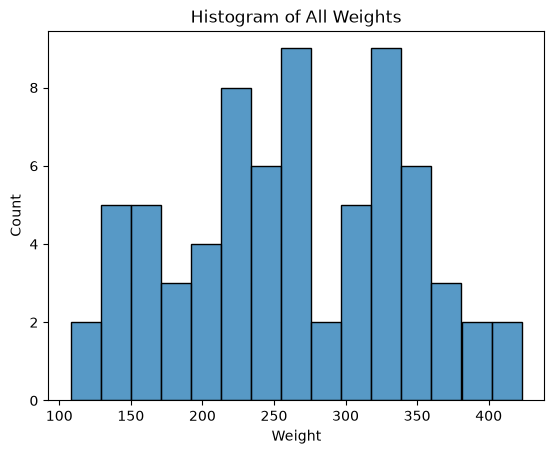

In [7]:
sns.histplot(data=df, x="weight", bins=15)
plt.title("Histogram of All Weights")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.show()

In [8]:
df2 = pd.read_csv("museum_visitors.csv")
df2

,Date,Avila Adobe,Firehouse Museum,Chinese American Museum,America Tropical Interpretive Center
0,2014-01-01,24778,4486,1581,6602
1,2014-02-01,18976,4172,1785,5029
2,2014-03-01,25231,7082,3229,8129
3,2014-04-01,26989,6756,2129,2824
4,2014-05-01,36883,10858,3676,10694
5,2014-06-01,29487,5751,2121,11036
6,2014-07-01,32378,5406,2239,13490
7,2014-08-01,37680,8619,1769,9139
8,2014-09-01,28473,61192,1073,5661
9,2014-10-01,27995,6488,1979,7356


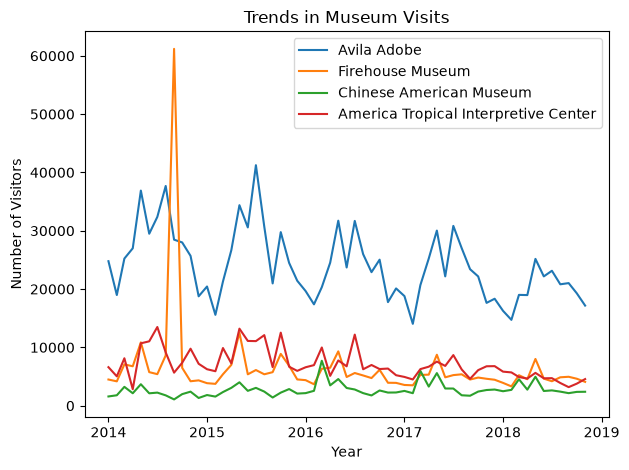

In [9]:
df2['Date'] = pd.to_datetime(df2['Date'])
sns.lineplot(data=df2, x="Date", y="Avila Adobe", label="Avila Adobe")
sns.lineplot(data=df2, x="Date", y="Firehouse Museum", label="Firehouse Museum")
sns.lineplot(data=df2, x="Date", y="Chinese American Museum", label="Chinese American Museum")
sns.lineplot(data=df2, x="Date", y="America Tropical Interpretive Center", label="America Tropical Interpretive Center")
plt.title("Trends in Museum Visits")
plt.xlabel("Year")
plt.ylabel("Number of Visitors")
plt.tight_layout()
plt.show()

I see a pattern where the number of visitors rise in the summer for all four museums.

In [10]:
df_sales = pd.read_csv("sales_clean.csv")
df_sales

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405
...,...,...,...,...,...,...
287,1103,2026-04-21,pen set,16.47,3,90405
288,1067,2026-04-27,backpack,37.93,5,90210
289,1025,2026-04-27,keyboard,47.30,2,2116
290,1196,2026-04-25,pen set,8.79,3,90405


In [11]:
df_sales["revenue"] = df_sales["price"] * df_sales["qty"]
df_sales

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36
...,...,...,...,...,...,...,...
287,1103,2026-04-21,pen set,16.47,3,90405,49.41
288,1067,2026-04-27,backpack,37.93,5,90210,189.65
289,1025,2026-04-27,keyboard,47.30,2,2116,94.60
290,1196,2026-04-25,pen set,8.79,3,90405,26.37


Text(0, 0.5, 'Revenue')

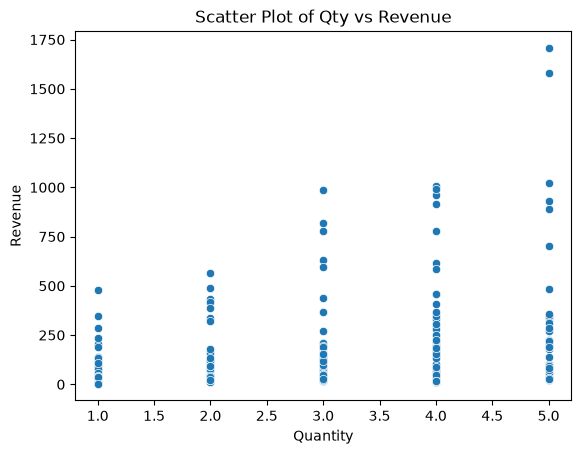

In [12]:
sns.scatterplot(data=df_sales, x="qty", y="revenue")
plt.title("Scatter Plot of Qty vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

<Axes: >

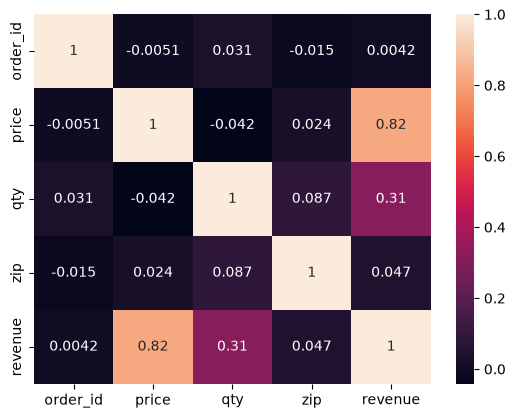

In [13]:
sns.heatmap(df_sales.corr(numeric_only=True), annot=True)

The strongest correlation seems to be the one between quantity and revenue with 0.31. It is closer to 1 than it is to -1, so it must have strong positive correlation.

Null Hypothesis: The chicks that are fed sunflower will have similar mean weight compared to the ones that are fed horsebean.

In [14]:
from scipy.stats import ttest_ind
a = df[df["feed"] == "sunflower"]["weight"]
b = df[df["feed"] == "horsebean"]["weight"]
ttest_ind(a, b)

TtestResult(statistic=np.float64(8.848346742516636), pvalue=np.float64(2.374350767683718e-08), df=np.float64(20.0))

The ttest results show a high number of t value and small value of p, which go against the null hypothesis and could mean that the type of feed (sunflower vs horsebean) did have a large impact on the mean weight of chicks. One caution to notice is that this is from a single person's farm, so there might be other factors (horsebean at the time could've gone bad, so chicks avoided eating them or the amount of sunflower given was just larger than the amount horsebean was given).

The lineplot for museum visitors had zero baseline and palette to make it easier to read and minimize distortion risk in the data.

Repo Address: https://github.com/yeonghwang-hub/cs82a-portfolio